# Homework 3: Python Fundamentals

This notebook uses NumPy and pandas to inspect, summarize, and visualize the provided dataset.

### 1. NumPy Operations

Create an array, apply elementwise operations, and compare a Python loop with NumPy vectorization.

In [1]:
from pathlib import Path
import timeit

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.utils import get_summary_stats

RAW_DATA_PATH = Path("data/raw/starter_data.csv")
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
numbers = np.array([1, 2, 3, 4, 5])

print("Original:", numbers)
print("Added 5:", numbers + 5)
print("Squared:", numbers ** 2)

Original: [1 2 3 4 5]
Added 5: [ 6  7  8  9 10]
Squared: [ 1  4  9 16 25]


In [3]:
large_array = np.arange(100_000)

loop_time = min(timeit.repeat(lambda: [value * 2 for value in large_array], number=3, repeat=3))
vector_time = min(timeit.repeat(lambda: large_array * 2, number=3, repeat=3))

print(f"Loop time: {loop_time:.6f} seconds")
print(f"Vectorized time: {vector_time:.6f} seconds")
print(f"Speedup: {loop_time / vector_time:.1f}x")

Loop time: 0.017444 seconds
Vectorized time: 0.000066 seconds
Speedup: 265.9x


### 2. Load and Inspect the Dataset

Load the provided CSV, check its structure, and preview the first five rows.

In [4]:
df = pd.read_csv(RAW_DATA_PATH, parse_dates=["date"])

print("DataFrame info:")
df.info()

print("\nFirst five rows:")
display(df.head())

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   category  10 non-null     object        
 1   value     10 non-null     int64         
 2   date      10 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 368.0+ bytes

First five rows:


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


### 3. Summary Statistics and Groupby

Use the reusable summary function and compare values across categories.

In [5]:
numeric_summary = get_summary_stats(df)
group_summary = (
    df.groupby("category", as_index=False)["value"]
    .agg(count="count", mean="mean", minimum="min", maximum="max")
)

print("Numeric summary:")
display(numeric_summary)

print("Summary by category:")
display(group_summary)

Numeric summary:


,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


Summary by category:


,category,count,mean,minimum,maximum
0,A,4,11.500000,10,13
1,B,3,15.666667,14,18
2,C,3,27.666667,25,30


### 4. Save Outputs

Save the numeric summary and a basic category chart in `data/processed/`.

In [6]:
summary_path = PROCESSED_DIR / "summary.csv"
numeric_summary.to_csv(summary_path, index_label="statistic")
print("Saved:", summary_path)

Saved: data\processed\summary.csv


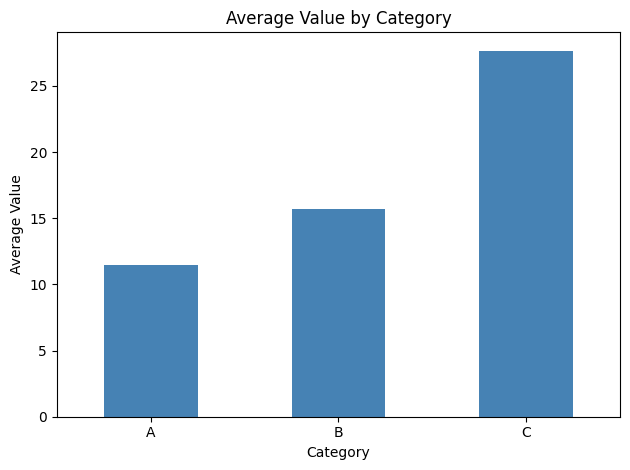

Saved: data\processed\category_mean.png


In [7]:
plot_path = PROCESSED_DIR / "category_mean.png"
category_means = df.groupby("category")["value"].mean()

ax = category_means.plot(kind="bar", color="steelblue", legend=False)
ax.set_title("Average Value by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

### 5. Key Findings

- NumPy vectorization is faster than the equivalent Python loop.
- Category C has the highest average value in the provided dataset.
- The processed summary and chart are saved for reuse.